In [1]:
import sys
sys.path.insert(0, '..') # make src/ importable from notebooks directory

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data import load_dataset
from src.models import BaselineModel
from src.trainer import Trainer
from src.evaluate import evaluate_model, print_results

In [4]:
MODEL_NAME = 'baseline' # used for checkpoint filename
DATASET = 'cub200'
BACKBONE = 'resnet34'  # 'resnet34' | 'vgg16'
NUM_CLASSES = 200
EPOCHS = 3
BATCH_SIZE = 64

LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_EVERY = 1 # validate every N epochs
PATIENCE = 3 # early stopping patience in epochs
PUSH_EPOCH = None # set to an int for prototype methods (e.g. 30)

NUM_WORKERS = 4
USE_BBOX_CROP = False

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'Device: {DEVICE}')

Device: mps


In [5]:
train_ds = load_dataset(DATASET, 'train', use_bbox_crop=USE_BBOX_CROP)
val_ds = load_dataset(DATASET, 'val', use_bbox_crop=USE_BBOX_CROP)
test_ds = load_dataset(DATASET, 'test', use_bbox_crop=USE_BBOX_CROP)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')

Train: 4,796 | Val: 1,198 | Test: 5,794


In [6]:
model = BaselineModel(backbone_name=BACKBONE, num_classes=NUM_CLASSES).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total:,} total | {trainable:,} trainable')

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
loss_fn = nn.CrossEntropyLoss()

trainer = Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn, scheduler=scheduler, device=DEVICE)

Parameters: 21,387,272 total | 21,387,272 trainable


In [7]:
history = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    val_every=VAL_EVERY,
    patience=PATIENCE,
    push_epoch=PUSH_EPOCH,
)


Epoch 1/3


  train_loss=4.5896 train_acc=0.1393 val_loss=3.5813 val_acc=0.3130

Epoch 2/3


  train_loss=2.8500 train_acc=0.5292 val_loss=2.5009 val_acc=0.5200

Epoch 3/3


  train_loss=1.8350 train_acc=0.7229 val_loss=1.9119 val_acc=0.6127


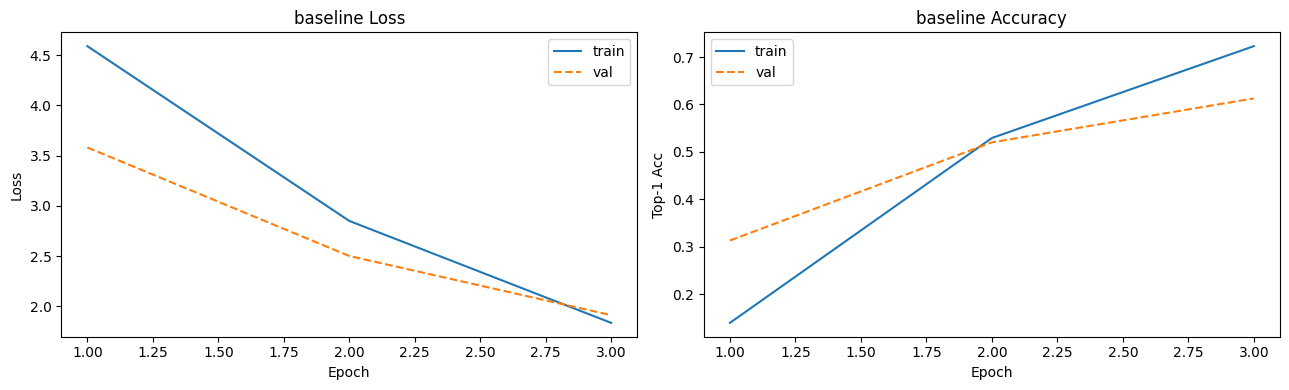

In [8]:
train_epochs = list(range(1, len(history['train_loss']) + 1))
val_epochs = history['val_epochs']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_epochs, history['train_loss'], label='train')
axes[0].plot(val_epochs, history['val_loss'], label='val', linestyle='--')

for key in history:
    if key not in ('train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_epochs', 'cls'):
        axes[0].plot(train_epochs[:len(history[key])], history[key], label=key, linestyle=':')

axes[0].set(title=f'{MODEL_NAME} Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend()

axes[1].plot(train_epochs, history['train_acc'], label='train')
axes[1].plot(val_epochs,   history['val_acc'],   label='val', linestyle='--')
axes[1].set(title=f'{MODEL_NAME} Accuracy', xlabel='Epoch', ylabel='Top-1 Acc')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'../results/{MODEL_NAME}_curves.png', dpi=150)
plt.show()

In [ ]:
trainer.save_checkpoint(
    f'../checkpoints/{MODEL_NAME}.pth',
    epoch=len(history['train_loss']),
    history=history
)

In [9]:
results = evaluate_model(model, test_loader, device=DEVICE)
print_results(results, model_name=MODEL_NAME)

[baseline] acc=0.6346  mean_per_class_acc=0.6354  inference=0.08ms/img  FLOPs=3,663,369,032


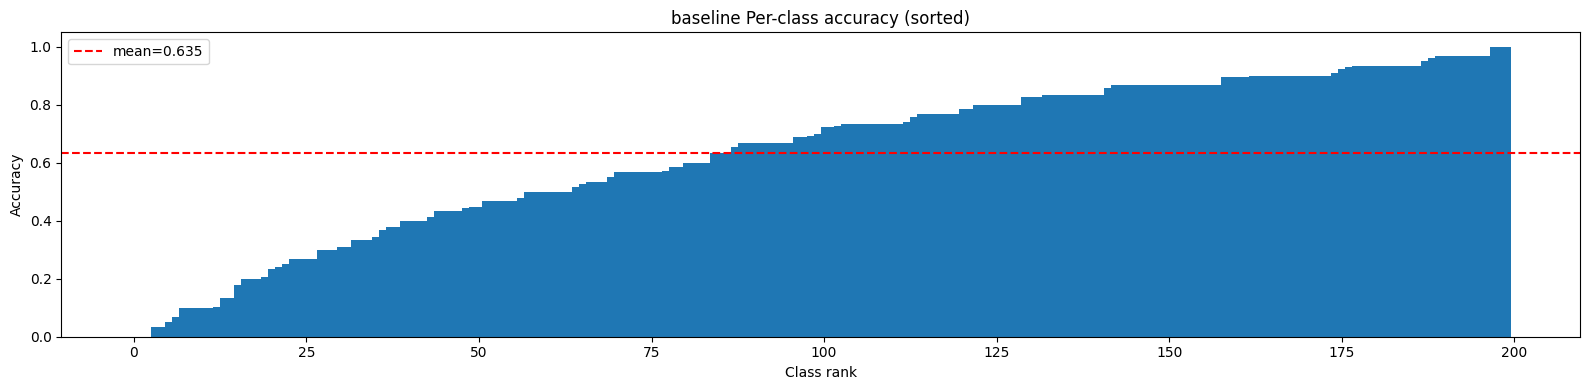

In [10]:
per_class = results['per_class_accuracy']

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(per_class)), sorted(per_class), width=1.0)
ax.axhline(per_class.mean(), color='red', linestyle='--', label=f'mean={per_class.mean():.3f}')

ax.set(title=f'{MODEL_NAME} Per-class accuracy (sorted)', xlabel='Class rank', ylabel='Accuracy')
ax.legend()

plt.tight_layout()
plt.savefig(f'../results/{MODEL_NAME}_per_class.png', dpi=150)
plt.show()